In [74]:
import PIL.Image
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import transforms

In [75]:
train_paths = sorted(glob.glob("train_images/*.png"))
train_labels = pd.read_csv("train.csv")['class']

test_paths = sorted(glob.glob("test_images/*.png"))


In [76]:
H = 100
W = 100

In [77]:
images = []

for path in train_paths:
    images.append(np.array(PIL.Image.open(path).resize((W, H))).reshape(-1))



In [78]:
from sklearn.decomposition import PCA

points = PCA(2).fit_transform(images)

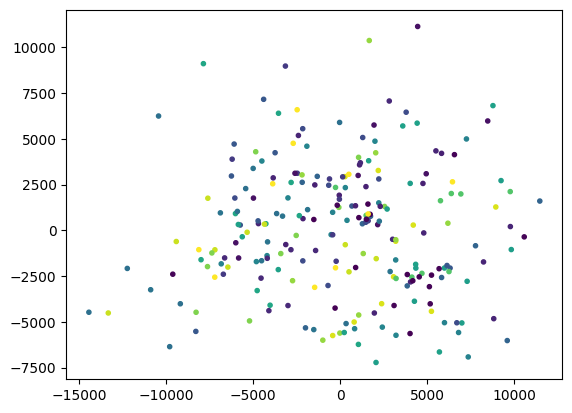

In [79]:
plt.scatter(points[:, 0], points[:, 1], c=train_labels, marker='.')

In [80]:
import torch
from torchvision.transforms import v2

images_tensor = torch.Tensor(images).reshape((-1, W, H, 3)).permute(0, 3, 1, 2)
all_imgs = []
all_labels = []

transforms = v2.Compose([
    v2.RandomResizedCrop(size=(W, H), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=(-100, 100)),
    
    # v2.RandomInvert(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

for i, img_ten in enumerate(images_tensor):

    all_imgs.append(img_ten / 255.0)
    all_labels.append(train_labels[i])

    for _ in range(20):
        all_imgs.append(transforms(img_ten) / 255.0)
        all_labels.append(train_labels[i])


In [81]:
len(all_labels)

4830

In [82]:
len(all_imgs)

4830

In [83]:
all_imgs[0]

tensor([[[0.7176, 0.7412, 0.6275,  ..., 0.9843, 0.9804, 0.9765],
         [0.7882, 0.8471, 0.7490,  ..., 0.9804, 0.9765, 0.9765],
         [0.8235, 0.9098, 0.7490,  ..., 0.9843, 0.9804, 0.9765],
         ...,
         [0.2275, 0.2078, 0.2196,  ..., 0.3098, 0.3020, 0.2863],
         [0.2235, 0.2157, 0.2039,  ..., 0.2902, 0.3020, 0.2980],
         [0.2039, 0.1961, 0.1882,  ..., 0.2980, 0.3020, 0.2863]],

        [[0.7686, 0.7765, 0.6549,  ..., 1.0000, 1.0000, 0.9961],
         [0.8235, 0.8784, 0.7804,  ..., 1.0000, 0.9961, 0.9961],
         [0.8667, 0.9451, 0.7804,  ..., 1.0000, 1.0000, 0.9961],
         ...,
         [0.2510, 0.2314, 0.2471,  ..., 0.3294, 0.3176, 0.2980],
         [0.2392, 0.2314, 0.2196,  ..., 0.3059, 0.3176, 0.3137],
         [0.2235, 0.2196, 0.2039,  ..., 0.3059, 0.3137, 0.3020]],

        [[0.7686, 0.7922, 0.6667,  ..., 1.0000, 1.0000, 1.0000],
         [0.8275, 0.8824, 0.7647,  ..., 1.0000, 1.0000, 1.0000],
         [0.8627, 0.9412, 0.7725,  ..., 1.0000, 1.0000, 1.

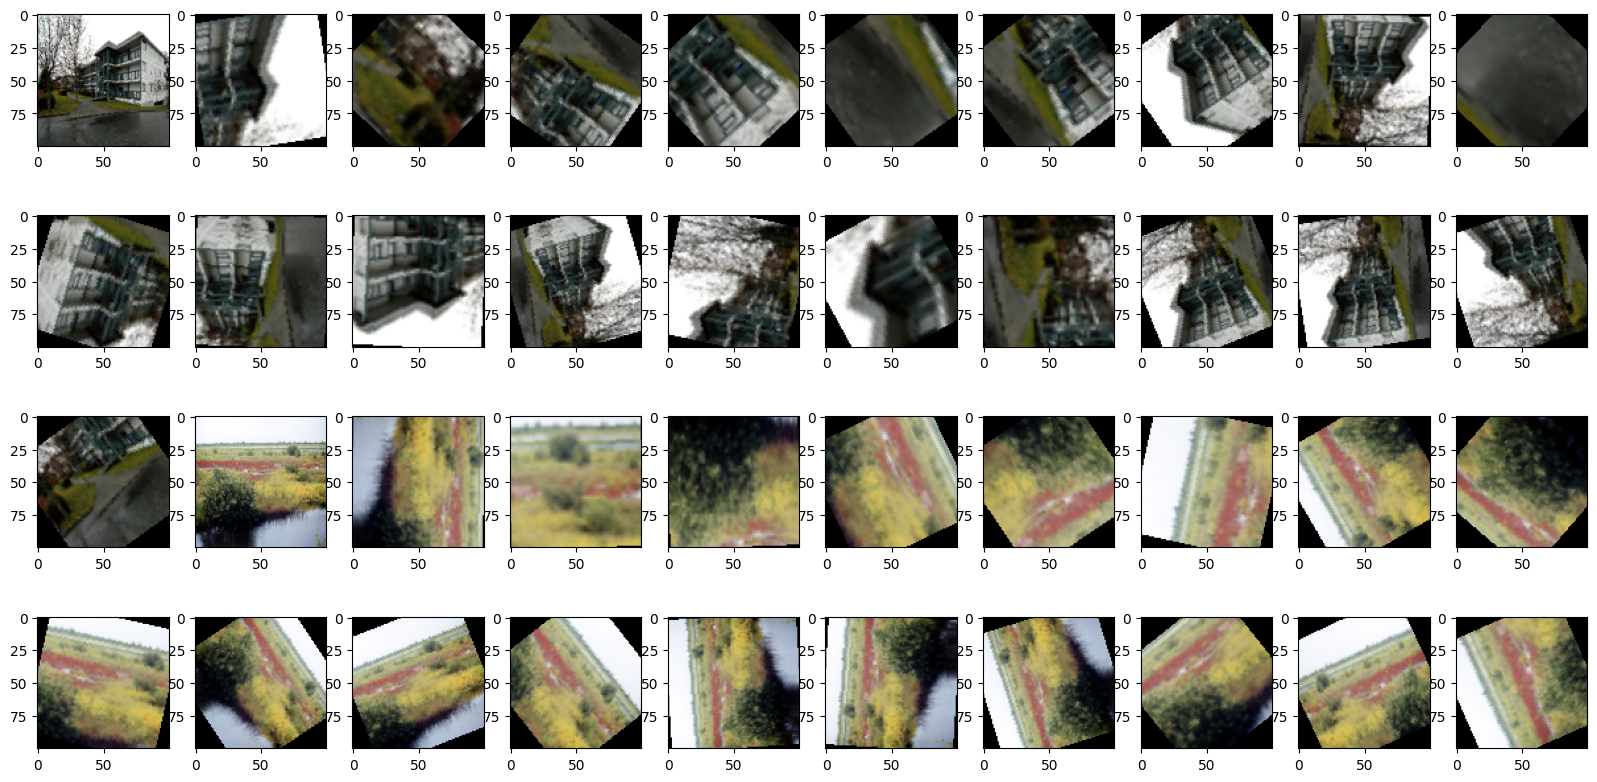

In [84]:
fig, ax = plt.subplots(4, 10);

fig.set_figwidth(20)
fig.set_figheight(10)


for i in range(10):
    ax[0][i].imshow(all_imgs[i].permute(1, 2, 0));
    ax[1][i].imshow(all_imgs[i + 10].permute(1, 2, 0));
    ax[2][i].imshow(all_imgs[i + 20].permute(1, 2, 0));
    ax[3][i].imshow(all_imgs[i + 30].permute(1, 2, 0));


In [85]:
all_imgs = np.array(all_imgs)

In [86]:
points = PCA(2).fit_transform(all_imgs.reshape(len(all_imgs), -1))

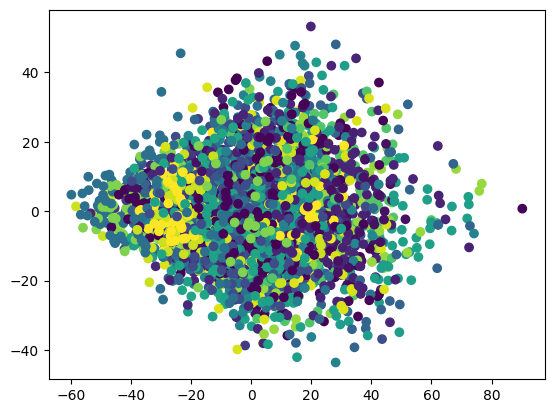

In [87]:
plt.scatter(points[:, 0], points[:, 1], c=all_labels)

In [88]:
import catboost
from sklearn.neural_network import *


model = MLPClassifier(verbose=1, max_iter=1000).fit(all_imgs.reshape(len(all_imgs), -1), all_labels)

Iteration 1, loss = 6.07392120
Iteration 2, loss = 3.14472948
Iteration 3, loss = 3.14398680
Iteration 4, loss = 3.14348489
Iteration 5, loss = 3.14311901
Iteration 6, loss = 3.14271856
Iteration 7, loss = 3.14225858
Iteration 8, loss = 3.14180745
Iteration 9, loss = 3.14139188
Iteration 10, loss = 3.14096609
Iteration 11, loss = 3.14060786
Iteration 12, loss = 3.14024369
Iteration 13, loss = 3.13991204
Iteration 14, loss = 3.13960316
Iteration 15, loss = 3.13929132
Iteration 16, loss = 3.13902321
Iteration 17, loss = 3.13873653
Iteration 18, loss = 3.13849594
Iteration 19, loss = 3.13824669
Iteration 20, loss = 3.13804846
Iteration 21, loss = 3.13787532
Iteration 22, loss = 3.13767242
Iteration 23, loss = 3.13751166
Iteration 24, loss = 3.13735260
Iteration 25, loss = 3.13723013
Iteration 26, loss = 3.13709126
Iteration 27, loss = 3.13697645
Iteration 28, loss = 3.13687705
Iteration 29, loss = 3.13676822
Iteration 30, loss = 3.13671628
Iteration 31, loss = 3.13661122
Iteration 32, los

In [89]:
import tqdm

test_images = []

for path in tqdm.tqdm(test_paths):
    test_images.append(np.array(PIL.Image.open(path).resize((W, H))).reshape(-1))



100%|██████████| 5100/5100 [00:17<00:00, 289.80it/s]


In [90]:
test_images_tensor = torch.Tensor(test_images).reshape((-1, W, H, 3)).permute(0, 3, 1, 2)


In [91]:
pred = model.predict(test_images_tensor.reshape(len(test_images_tensor), -1))

In [92]:
ans = pd.DataFrame()

classes = []
ids = []

id = 0;

for i, p in enumerate(pred):
    classes.append(55);
    ids.append(test_paths[i].split("/")[1]);

ans["id"] = ids;
ans["class"] = classes



In [93]:
ans.to_csv("ans.csv", index=False)